# Gold Price Prediction Project — Template


## 1. Imports & Load Data

In [88]:
# write your code here
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



import matplotlib.pyplot as plt

In [89]:
import kagglehub
import os

path = kagglehub.dataset_download("hayaalwizrah1/gold-price-prediction-dataset-20002026")
data = pd.read_csv(os.path.join(path, 'gold_data.csv'))

Using Colab cache for faster access to the 'gold-price-prediction-dataset-20002026' dataset.


In [90]:
df = pd.DataFrame(data=data)
df.head()

,Date,Gold_Open,Gold_High,Gold_Low,Gold_Close,Gold_Volume,DXY,SP500,Oil,VIX,...,Daily_Return,RSI,MACD,MACD_Signal,MACD_Hist,BB_Upper,BB_Middle,BB_Lower,ATR,Target
0,2000-10-18,270.299988,270.299988,270.299988,270.299988,0.0,117.330002,1342.130005,33.549999,28.719999,...,-0.002951,44.027677,-0.811933,-0.890278,0.078346,277.007532,272.364998,267.722464,1.797421,270.100006
1,2000-10-19,270.100006,270.100006,270.100006,270.100006,1.0,116.940002,1388.760010,32.950001,25.090000,...,-0.000740,43.589968,-0.887787,-0.889780,0.001993,277.016104,272.354999,267.693893,1.683319,271.200012
2,2000-10-20,271.200012,271.200012,271.200012,271.200012,32.0,117.160004,1396.930054,34.299999,24.240000,...,0.004073,46.727258,-0.849350,-0.881694,0.032344,277.007681,272.325000,267.642319,1.641653,270.100006
3,2000-10-23,271.700012,271.700012,270.100006,270.100006,1.0,117.540001,1395.780029,33.730000,24.690001,...,-0.004056,44.086729,-0.897306,-0.884817,-0.012490,276.828986,272.125000,267.421014,1.638679,270.100006
4,2000-10-24,269.799988,270.100006,269.799988,270.100006,16.0,117.419998,1398.130005,33.369999,24.280001,...,0.000000,44.086729,-0.924653,-0.892784,-0.031869,276.643831,271.935001,267.226170,1.543060,266.200012


In [91]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date', ascending=True)
df = df.reset_index(drop=True)

In [92]:
df.head()

,Date,Gold_Open,Gold_High,Gold_Low,Gold_Close,Gold_Volume,DXY,SP500,Oil,VIX,...,Daily_Return,RSI,MACD,MACD_Signal,MACD_Hist,BB_Upper,BB_Middle,BB_Lower,ATR,Target
0,2000-10-18,270.299988,270.299988,270.299988,270.299988,0.0,117.330002,1342.130005,33.549999,28.719999,...,-0.002951,44.027677,-0.811933,-0.890278,0.078346,277.007532,272.364998,267.722464,1.797421,270.100006
1,2000-10-19,270.100006,270.100006,270.100006,270.100006,1.0,116.940002,1388.760010,32.950001,25.090000,...,-0.000740,43.589968,-0.887787,-0.889780,0.001993,277.016104,272.354999,267.693893,1.683319,271.200012
2,2000-10-20,271.200012,271.200012,271.200012,271.200012,32.0,117.160004,1396.930054,34.299999,24.240000,...,0.004073,46.727258,-0.849350,-0.881694,0.032344,277.007681,272.325000,267.642319,1.641653,270.100006
3,2000-10-23,271.700012,271.700012,270.100006,270.100006,1.0,117.540001,1395.780029,33.730000,24.690001,...,-0.004056,44.086729,-0.897306,-0.884817,-0.012490,276.828986,272.125000,267.421014,1.638679,270.100006
4,2000-10-24,269.799988,270.100006,269.799988,270.100006,16.0,117.419998,1398.130005,33.369999,24.280001,...,0.000000,44.086729,-0.924653,-0.892784,-0.031869,276.643831,271.935001,267.226170,1.543060,266.200012


## 2. Quick Data Exploration (EDA)

In [93]:
# write your code here
df.shape

(6468, 25)

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6468 entries, 0 to 6467
Data columns (total 25 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          6468 non-null   datetime64[ns]
 1   Gold_Open     6468 non-null   float64       
 2   Gold_High     6468 non-null   float64       
 3   Gold_Low      6468 non-null   float64       
 4   Gold_Close    6468 non-null   float64       
 5   Gold_Volume   6468 non-null   float64       
 6   DXY           6468 non-null   float64       
 7   SP500         6468 non-null   float64       
 8   Oil           6468 non-null   float64       
 9   VIX           6468 non-null   float64       
 10  Lag1          6468 non-null   float64       
 11  Lag7          6468 non-null   float64       
 12  MA7           6468 non-null   float64       
 13  MA30          6468 non-null   float64       
 14  EMA20         6468 non-null   float64       
 15  Daily_Return  6468 non-null   float64 

In [95]:
df.describe()

,Date,Gold_Open,Gold_High,Gold_Low,Gold_Close,Gold_Volume,DXY,SP500,Oil,VIX,...,Daily_Return,RSI,MACD,MACD_Signal,MACD_Hist,BB_Upper,BB_Middle,BB_Lower,ATR,Target
count,6468,6468.000000,6468.000000,6468.000000,6468.000000,6468.000000,6468.000000,6468.000000,6468.000000,6468.000000,...,6468.000000,6468.000000,6468.000000,6468.000000,6468.000000,6468.000000,6468.000000,6468.000000,6468.000000,6468.000000
mean,2013-09-15 23:17:01.892393216,1331.326408,1338.590121,1323.732607,1331.278663,4289.251237,92.508420,2405.750051,65.248230,19.743652,...,0.000484,52.922866,4.177401,4.209752,-0.032351,1374.027614,1325.715645,1277.403675,17.656730,1331.862893
min,2000-10-18 00:00:00,255.000000,256.100006,255.000000,255.100006,0.000000,71.330002,676.530029,-37.630001,9.140000,...,-0.113662,16.555742,-152.862263,-115.158309,-95.153851,262.690584,259.269998,252.954794,0.858960,255.100006
25%,2007-04-17 18:00:00,662.500000,665.200012,660.724991,662.500000,24.000000,82.599998,1209.544952,47.097499,13.970000,...,-0.004845,44.500461,-4.174402,-3.937399,-2.144649,684.193391,662.072501,639.583150,7.429916,662.574982
50%,2013-09-17 12:00:00,1258.549988,1265.600037,1253.450012,1258.400024,121.000000,93.235001,1693.320007,64.455002,17.585000,...,0.000519,52.434576,1.816377,1.732898,0.141395,1296.852761,1260.665005,1218.915205,14.667469,1258.599976
75%,2020-02-25 06:00:00,1719.375031,1728.325043,1708.950012,1719.925049,467.000000,99.512501,3087.815002,82.699997,23.012500,...,0.006401,61.602148,11.067144,10.772167,2.370561,1777.566373,1719.417505,1662.596157,20.780509,1720.325043
max,2026-07-30 00:00:00,5415.700195,5586.200195,5301.600098,5318.399902,386334.000000,120.900002,7609.779785,145.289993,82.690002,...,0.090277,87.904154,227.374043,170.076845,62.694653,5530.114159,5119.044971,4941.546783,200.652560,5318.399902
std,NaN,874.129231,880.732577,866.927261,873.866684,23983.824104,11.006872,1619.893786,24.513317,8.392199,...,0.011262,12.197426,21.995293,20.787465,6.302385,909.924973,867.760295,826.979542,18.848183,874.420246


In [96]:
df.isnull().sum()

,0
Date,0
Gold_Open,0
Gold_High,0
Gold_Low,0
Gold_Close,0
Gold_Volume,0
DXY,0
SP500,0
Oil,0
VIX,0


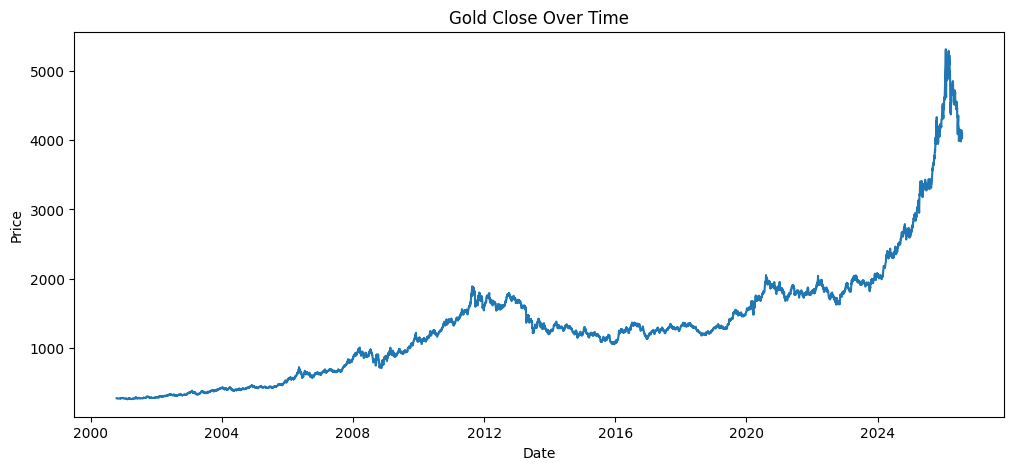

In [97]:
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Gold_Close'])
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Gold Close Over Time')
plt.show()

## 3. Define Features and Target

In [98]:
# write your code here
y = df['Target']
X = df.drop(columns=["Date","Target", "Lag1","Gold_Close","Daily_Return"],axis=1)


In [99]:
y.shape, X.shape

((6468,), (6468, 20))

## 4. Chronological Split (Train / Validation / Test)

In [100]:
n = len(X)
train_end = int(n * 0.70)
val_end = int(n * 0.85)   # 0.70 + 0.15

In [101]:
X_train = X[:train_end]
X_val = X[train_end:val_end]
X_test = X[val_end:]

In [102]:
y_train = y[:train_end]
y_val = y[train_end:val_end]
y_test = y[val_end:]

In [103]:
print(X_train.shape[0] == y_train.shape[0])
print(X_val.shape[0] == y_val.shape[0])
print(X_test.shape[0] == y_test.shape[0])

True
True
True


In [104]:
X_train.shape[0] + X_val.shape[0] + X_test.shape[0]

6468

## 5. Scaling

In [105]:
# write your code here
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [106]:
X_train_scaled.mean(axis=0)

array([-5.02261267e-17, -1.00452253e-16,  0.00000000e+00,  0.00000000e+00,
        3.51582887e-16, -1.00452253e-16,  2.51130633e-17, -1.25565317e-16,
        1.50678380e-16,  2.51130633e-16, -3.01356760e-16, -5.02261267e-17,
        1.63234912e-16, -1.25565317e-17,  1.25565317e-17,  5.88587422e-18,
       -1.00452253e-16, -2.00904507e-16, -3.51582887e-16,  0.00000000e+00])

## 6. Baseline

In [107]:
# write your code here
baseline_pred = df['Gold_Close'][val_end:]      # today's price, used as the naive guess for tomorrow
baseline_mae = mean_absolute_error(y_test, baseline_pred)

print(baseline_mae)

27.46436628033278


In [108]:
 baseline_pred.shape[0] == y_test.shape[0]

True

## 7. Build & Compile & Train the Model (Dense Network)

In [109]:
# write your code here
def build_model():
    model = keras.Sequential([
        keras.layers.Dense(256, activation='relu', input_shape=(20,)),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mae",
        metrics=["mae"]
    )
    return model

model = build_model()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [110]:
X_train_scaled.shape[1]

20

In [110]:
# هنا جربت بدون early stop
#history = model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_data=(X_val_scaled, y_val))

## 8. Early Stop

In [112]:
# write your code here

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_scaled, y_val),
    callbacks=[early_stop]
)

Epoch 1/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 716.5787 - mae: 716.5787 - val_loss: 740.5803 - val_mae: 740.5803
Epoch 2/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 228.2432 - mae: 228.2432 - val_loss: 804.0511 - val_mae: 804.0511
Epoch 3/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 151.9031 - mae: 151.9031 - val_loss: 680.2869 - val_mae: 680.2869
Epoch 4/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 121.2418 - mae: 121.2418 - val_loss: 581.0199 - val_mae: 581.0199
Epoch 5/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 105.7200 - mae: 105.7200 - val_loss: 496.8123 - val_mae: 496.8123
Epoch 6/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 89.3841 - mae: 89.3841 - val_loss: 378.7264 - val_mae: 378.7264
Epoch 7/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 81.1607 - mae: 81.1607 - val_loss: 276.8482 - val_mae: 276.8482
Epoch 8/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 73.5857 - mae: 73.5857 - val_loss: 177.8060 - val_mae: 177.80

## 9. Evaluation


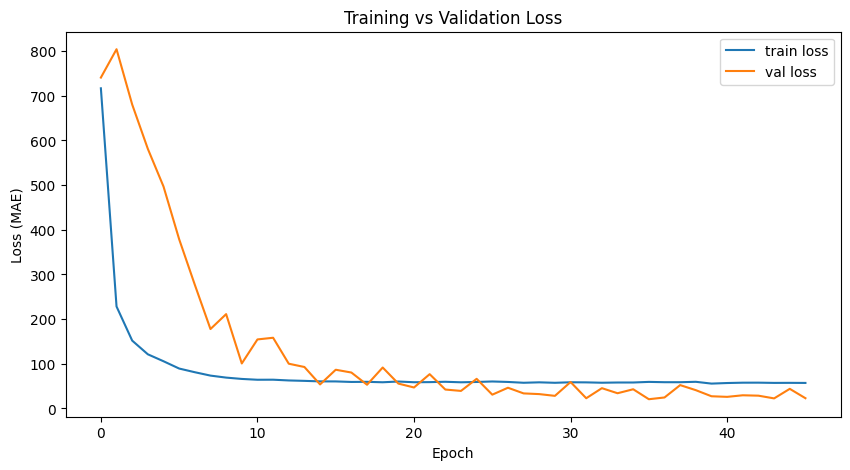

In [114]:
# write your code here
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MAE)')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [115]:
y_pred = model.predict(X_test_scaled).flatten()

test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Test MAE:", test_mae)
print("Test RMSE:", test_rmse)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Test MAE: 67.78514594128154
Test RMSE: 102.83921802028874


In [116]:
print("Baseline MAE:", baseline_mae)
print("Model MAE:", test_mae)
print("Improvement:", (baseline_mae - test_mae) / baseline_mae * 100, "%")

Naive baseline MAE: 27.46436628033278
Model MAE: 67.78514594128154
Improvement: -146.81125080181607 %


In [117]:
print("y_train range:", y_train.min(), "-", y_train.max())
print("y_val range:", y_val.min(), "-", y_val.max())
print("y_test range:", y_test.min(), "-", y_test.max())
# عشان كذا ممكن طريقة التقسيمة هي اللي تحتاج تحسين

y_train range: 255.1000061035156 - 1888.699951171875
y_val range: 1199.199951171875 - 2051.5
y_test range: 1623.300048828125 - 5318.39990234375


## 10. Conclusion
- Summarize your best result compared to the baseline
- State the limitations (e.g. the price+indicators model doesn't account for sudden political events, data is daily only...)